# **DQN vs Double DQN**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

## **1. Load rewards**

In [2]:
dqn_rewards = np.load('../results/dqn_v1_big_buffer_2000_episodes_rewards.npy', allow_pickle=True)
double_dqn_rewards = np.load('../results/double_dqn_v1_rewards.npy', allow_pickle=True)

print(f'DQN       : {len(dqn_rewards)} episodes')
print(f'Double DQN: {len(double_dqn_rewards)} episodes')

DQN       : 2000 episodes
Double DQN: 5000 episodes


## **2. Training curves**

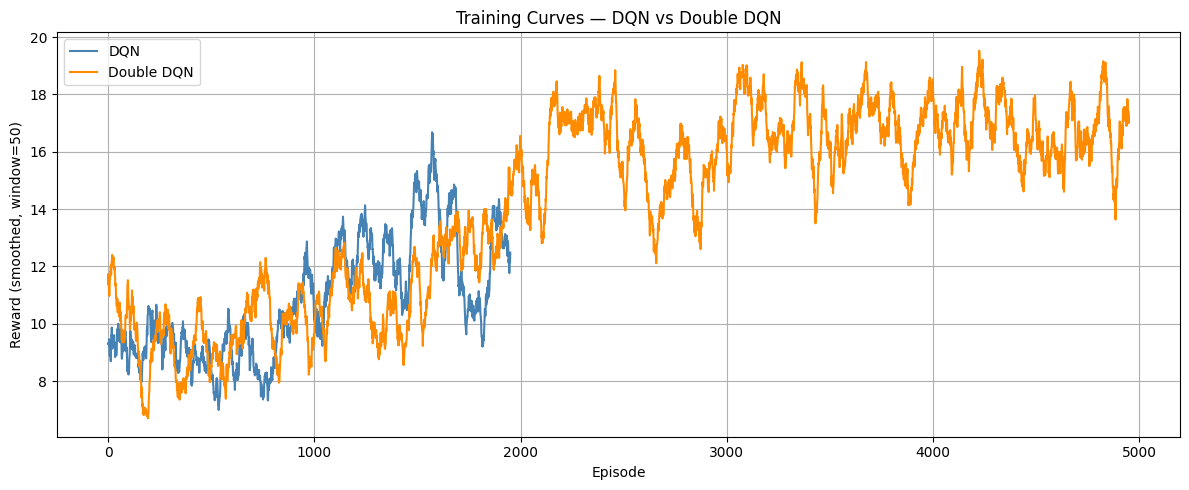

In [3]:
def smooth(rewards, window=50):
    return np.convolve(rewards, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 5))

plt.plot(smooth(dqn_rewards),       label='DQN',        color='steelblue')
plt.plot(smooth(double_dqn_rewards), label='Double DQN', color='darkorange')

plt.xlabel('Episode')
plt.ylabel('Reward (smoothed, window=50)')
plt.title('Training Curves — DQN vs Double DQN')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../results/comparison_curves.png', dpi=150)
plt.show()

## **3. Performance table (last 200 episodes)**

In [4]:
last_n = 200

dqn_last        = dqn_rewards[-last_n:]
double_dqn_last = double_dqn_rewards[-last_n:]

print(f"{'Model':<15} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print('-' * 55)
print(f"{'DQN':<15} {np.mean(dqn_last):>10.2f} {np.std(dqn_last):>10.2f} {np.min(dqn_last):>10.2f} {np.max(dqn_last):>10.2f}")
print(f"{'Double DQN':<15} {np.mean(double_dqn_last):>10.2f} {np.std(double_dqn_last):>10.2f} {np.min(double_dqn_last):>10.2f} {np.max(double_dqn_last):>10.2f}")

Model                 Mean        Std        Min        Max
-------------------------------------------------------
DQN                  12.14       7.33       0.97      28.15
Double DQN           16.84       8.24       1.05      29.95


## **4. Distribution of rewards (last 200 episodes)**

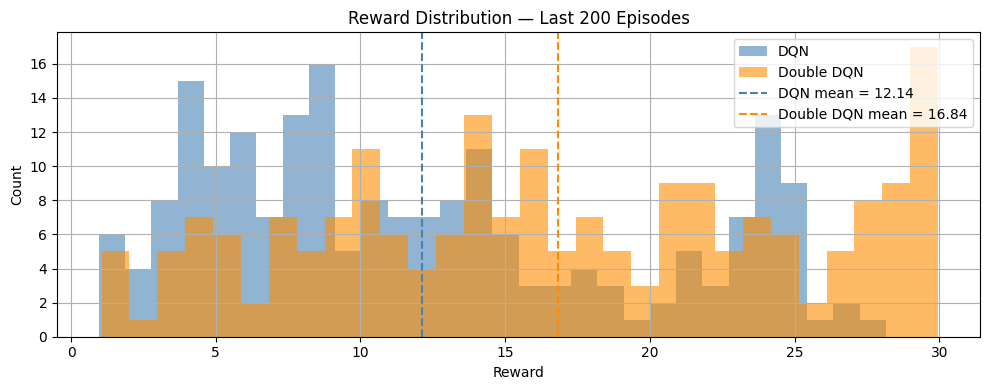

In [5]:
plt.figure(figsize=(10, 4))

plt.hist(dqn_last,        bins=30, alpha=0.6, label='DQN',        color='steelblue')
plt.hist(double_dqn_last, bins=30, alpha=0.6, label='Double DQN', color='darkorange')

plt.axvline(np.mean(dqn_last),        color='steelblue',  linestyle='--', label=f'DQN mean = {np.mean(dqn_last):.2f}')
plt.axvline(np.mean(double_dqn_last), color='darkorange', linestyle='--', label=f'Double DQN mean = {np.mean(double_dqn_last):.2f}')

plt.xlabel('Reward')
plt.ylabel('Count')
plt.title('Reward Distribution — Last 200 Episodes')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../results/comparison_distribution.png', dpi=150)
plt.show()

## **5. Rollouts**

In [18]:
from IPython.display import HTML, display

print('DQN rollout:')
display(HTML('<img src="../results/dqn_v1_big_buffer_2000_episodes_rollout.gif">'))

print('Double DQN rollout:')
display(HTML('<img src="../results/double_dqn_v1_rollout.gif">'))

DQN rollout:


Double DQN rollout:


In [10]:
import imageio
frames = imageio.mimread('../results/double_dqn_v1_rollout.gif')
print(f'Nombre de frames : {len(frames)}')

Nombre de frames : 31


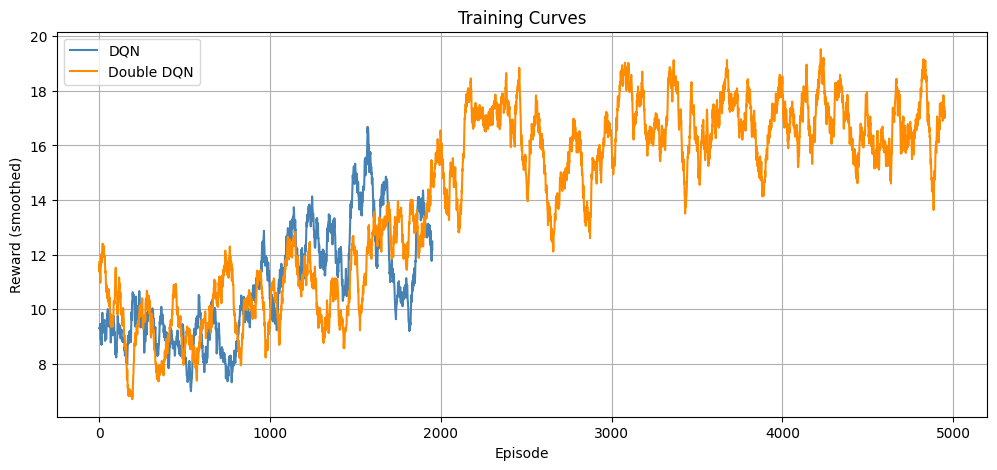

In [14]:
import numpy as np
import matplotlib.pyplot as plt

dqn_rewards        = np.load('../results/dqn_v1_big_buffer_2000_episodes_rewards.npy')
double_dqn_rewards = np.load('../results/double_dqn_v1_rewards.npy')

def smooth(rewards, window=50):
    return np.convolve(rewards, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 5))
plt.plot(smooth(dqn_rewards),        label='DQN',        color='steelblue')
plt.plot(smooth(double_dqn_rewards), label='Double DQN', color='darkorange')
plt.xlabel('Episode')
plt.ylabel('Reward (smoothed)')
plt.title('Training Curves')
plt.legend()
plt.grid(True)
plt.savefig('../results/comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()

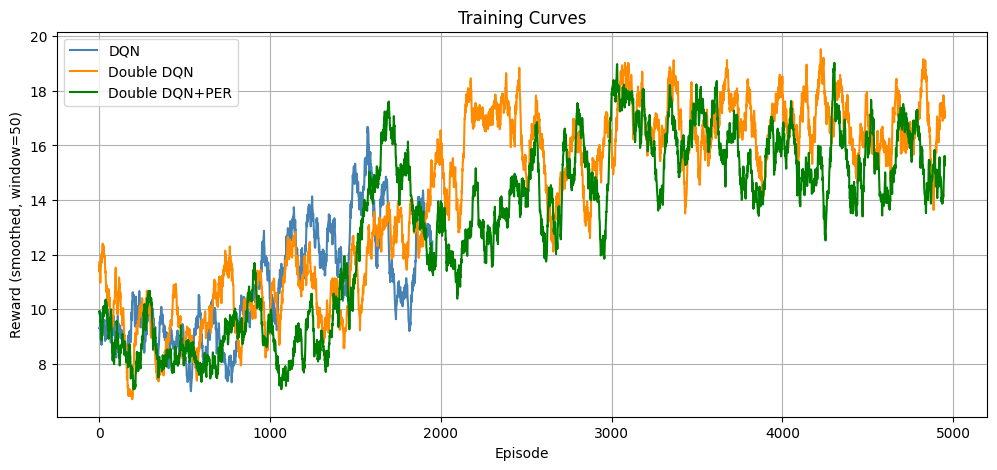

In [17]:
import numpy as np
import matplotlib.pyplot as plt

dqn_rewards     = np.load('../results/dqn_v1_big_buffer_2000_episodes_rewards.npy')
ddqn_rewards    = np.load('../results/double_dqn_v1_rewards.npy')
per_rewards     = np.load('../results/double_dqn_per_v1_rewards.npy')

def smooth(rewards, window=50):
    return np.convolve(rewards, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 5))
plt.plot(smooth(dqn_rewards),  label='DQN',            color='steelblue')
plt.plot(smooth(ddqn_rewards), label='Double DQN',     color='darkorange')
plt.plot(smooth(per_rewards),  label='Double DQN+PER', color='green')
plt.xlabel('Episode')
plt.ylabel('Reward (smoothed, window=50)')
plt.title('Training Curves')
plt.legend()
plt.grid(True)
plt.savefig('../results/comparison_curves_all.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
dqn_rewards     = np.load('../results/dqn/dqn_v2_2_layers_rewards.npy')
ddqn_rewards    = np.load('../results/double_dqn_v1_rewards.npy')
per_rewards     = np.load('../results/double_dqn_per_v1_rewards.npy')

print(f'DQN        : {len(dqn_rewards)} episodes')
print(f'Double DQN : {len(ddqn_rewards)} episodes')
print(f'PER        : {len(per_rewards)} episodes')

DQN        : 4000 episodes
Double DQN : 5000 episodes
PER        : 5000 episodes


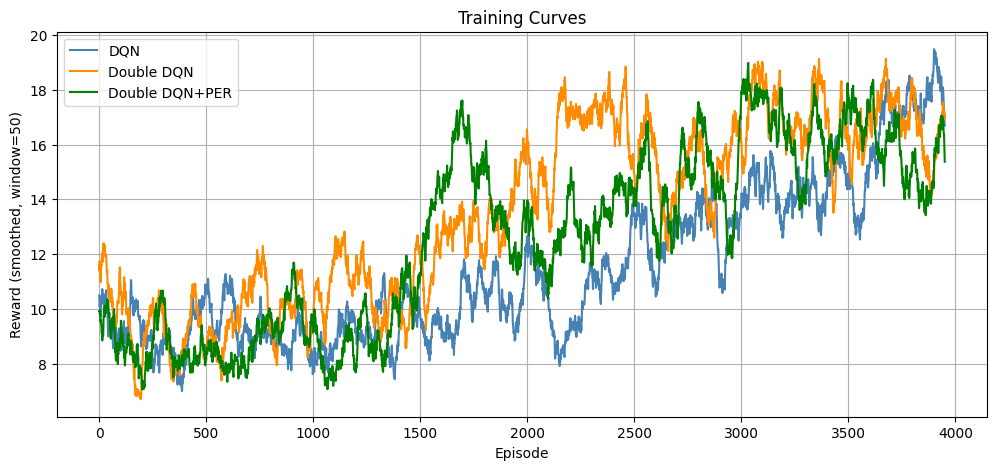

In [56]:
plt.figure(figsize=(12, 5))
plt.plot(smooth(dqn_rewards),          label='DQN',            color='steelblue')
plt.plot(smooth(ddqn_rewards[:4000]),  label='Double DQN',     color='darkorange')
plt.plot(smooth(per_rewards[:4000]),   label='Double DQN+PER', color='green')
plt.xlabel('Episode')
plt.ylabel('Reward (smoothed, window=50)')
plt.title('Training Curves')
plt.legend()
plt.grid(True)
plt.savefig('../results/comparison_curves_all.png', dpi=150, bbox_inches='tight')
plt.show()

In [57]:
print(f"DQN        mean (last 2000): {np.mean(dqn_rewards[-2000:]):.2f} | std: {np.std(dqn_rewards[-50:]):.2f}")
print(f"Double DQN mean (last 2000): {np.mean(ddqn_rewards[-2000:]):.2f} | std: {np.std(ddqn_rewards[-50:]):.2f}")
print(f"PER        mean (last 2000): {np.mean(per_rewards[-2000:]):.2f} | std: {np.std(per_rewards[-50:]):.2f}")

DQN        mean (last 2000): 13.57 | std: 6.59
Double DQN mean (last 2000): 16.87 | std: 8.31
PER        mean (last 2000): 15.86 | std: 7.81
